# Chapter 5.2 sci-Plex Perturbation Prediction

**TL;DR** — Evaluates condition-aware perturbation prediction on real sci-Plex A549 data for Split B held-out highest dose and Split C held-out compound. The reader finishes with split tables, RDKit2D audit/cache files, metric summaries, Section 5.2 figures, and the perturbation run summary.

**Prerequisites** - Chapter 5.1 (time-course suite) and Chapter 4.1 (coupling geometry).

**Outputs**
- `figures/ch05/new2/fig_5_2_model_designs.png`
- `figures/ch05/new2/fig_5_2_model_designs.pdf`
- `figures/ch05/new2/fig_5_2_evaluation_splits.png`
- `figures/ch05/new2/fig_5_2_evaluation_splits.pdf`
- `figures/ch05/new2/fig_5_2_heldout_highest_dose_metrics.png`
- `figures/ch05/new2/fig_5_2_heldout_highest_dose_metrics.pdf`
- `figures/ch05/new2/fig_5_2_heldout_compound_metrics.png`
- `figures/ch05/new2/fig_5_2_heldout_compound_metrics.pdf`
- `figures/ch05/new2/fig_5_2_alisertib_example.png`
- `figures/ch05/new2/fig_5_2_alisertib_example.pdf`
- `tables/ch05/tab_5_2_sciplex_splits.csv`
- `outputs/ch05/real_data_audit.json`
- `outputs/ch05/rdkit2d_compound_features.npz`
- `outputs/ch05/rdkit2d_diagnostics.json`
- `outputs/ch05/rdkit2d_audit.csv`
- `outputs/ch05/sciplex_metrics_by_group.csv`
- `outputs/ch05/sciplex_metrics_summary.csv`
- `outputs/ch05/run_summary_perturbation_sciplex.json`

**Runtime** - `QUICK_MODE` is controlled by `CH05_QUICK` and is off by default; this notebook does not define a separate `SMOKE_MODE`. On CPU, the full perturbation evaluation is long because it trains/evaluates both held-out splits, while `CH05_QUICK` and `CH05_MAX_EVAL_GROUPS` can shrink exploratory runs.

**Key parameters**
- `DEFAULT_SEED` defaults to `42` via `CH05_SEED`.
- `QUICK_MODE` defaults to `False` via `CH05_QUICK=0`.
- `TRAINING_STEPS` defaults to `6000`; `BATCH_SIZE` defaults to `256`; `NFE` defaults to `32`.
- Split B is held-out highest dose; Split C is held-out compound.
- RDKit2D compound features are used by the chemistry-aware model.
- `CH05_MAX_EVAL_GROUPS` optionally limits evaluation groups for smaller runs.

## 0. Setup, run configuration, and shared utilities

The setup is split into imports, deterministic run configuration, output folders, plotting defaults, and save helpers. Keep these visible because later cells depend on the same seed, device, and artifact directories; the printed paths are repository-relative so the notebook does not expose machine-specific absolute paths.

### Hypothesis
This setup assumes the perturbation-response section can share one deterministic sci-Plex configuration across data audit, split evaluation, and figure generation. Section 5.2 Perturbation prediction with sci-Plex uses `CONFIG = ch05s.make_section52_config(PROJECT_ROOT)` and `DEFAULT_SEED = CONFIG.default_seed`.

### Setup
The cells define `TRAINING_STEPS = CONFIG.training_steps`, `SCIPLEX_DOWNLOAD_IN_CH05 = CONFIG.sciplex_download_in_ch05`, `SCIPLEX_SYNTHETIC_IF_MISSING = CONFIG.sciplex_synthetic_if_missing`, and `MAX_EVAL_GROUPS = CONFIG.max_eval_groups`. They also use `import random`, `random.seed(DEFAULT_SEED)`, `np.random.seed(DEFAULT_SEED)`, `torch.manual_seed(DEFAULT_SEED)`, `torch.cuda.manual_seed_all(DEFAULT_SEED)`, `torch.backends.cudnn.benchmark = False`, `torch.backends.cudnn.deterministic = True`, and `torch.use_deterministic_algorithms(True, warn_only=True)`.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch05_perturbation")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from IPython.display import Markdown

try:
    import torch
except Exception as exc:
    raise ImportError("Chapter 5 perturbation experiments require PyTorch.") from exc

import sys

ROOT_HINT = Path.cwd().resolve()
if not (ROOT_HINT / "src").is_dir():
    ROOT_HINT = ROOT_HINT.parent
if str(ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(ROOT_HINT))

from src.tutorial_init import bootstrap

DEFAULT_SEED = int(os.environ.get("CH05_SEED", "42"))
QUICK_MODE = os.environ.get("CH05_QUICK", "0") == "1"
boot = bootstrap(chapter="ch05", seed=DEFAULT_SEED, quick_mode=QUICK_MODE)
PROJECT_ROOT = boot.project_root
FIG_DIR = boot.fig_dir
OUT_DIR = boot.out_dir
DEVICE = boot.device

from src.artifacts import save_csv, save_json
from src.data.loading import (
    load_or_prepare_sciplex3_a549,
    load_lincs_smiles_corpus,
    make_sciplex_split,
    make_sciplex_pca_state_table,
    compute_rdkit2d_with_external_norm,
)
from src.experiments.perturbation import (
    set_global_seed,
    choose_heldout_compound,
    sciplex_split_counts,
    evaluate_sciplex_split,
    aggregate_metric_table,
)
import src.visualization.perturbation as ch05s

CONFIG = ch05s.make_section52_config(PROJECT_ROOT)
PROJECT_ROOT = CONFIG.project_root
DATA_DIR = CONFIG.data_dir
FIG_DIR = CONFIG.fig_dir
TABLE_DIR = CONFIG.table_dir
OUT_DIR = CONFIG.output_dir
DEFAULT_SEED = CONFIG.default_seed
QUICK_MODE = CONFIG.quick_mode
TRAINING_STEPS = CONFIG.training_steps
BATCH_SIZE = CONFIG.batch_size
NFE = CONFIG.nfe
SCIPLEX_DOWNLOAD_IN_CH05 = CONFIG.sciplex_download_in_ch05
SCIPLEX_SYNTHETIC_IF_MISSING = CONFIG.sciplex_synthetic_if_missing
MAX_EVAL_GROUPS = CONFIG.max_eval_groups
DEVICE = CONFIG.device

print("Project root resolved")

set_global_seed(DEFAULT_SEED)
random.seed(DEFAULT_SEED)
np.random.seed(DEFAULT_SEED)
torch.manual_seed(DEFAULT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(DEFAULT_SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

print(f"Device: {DEVICE}; quick={QUICK_MODE}; steps={TRAINING_STEPS}; batch={BATCH_SIZE}; nfe={NFE}")
print("Artifacts: figures/ch05/new2, tables/ch05, outputs/ch05")
print("Evaluated splits: Split B held-out highest dose; Split C held-out compound")


project_root=..
seed=42
quick_mode=False
fig_dir=figures/ch05
out_dir=outputs/ch05
device=cuda
Project root resolved
Device: cuda; quick=False; steps=6000; batch=256; nfe=32
Artifacts: figures/ch05/new2, tables/ch05, outputs/ch05
Evaluated splits: Split B held-out highest dose; Split C held-out compound


In [2]:

ch05s.apply_section52_plot_style()
RUN_SUMMARY = ch05s.make_section52_run_summary(CONFIG)


In [3]:
METHOD_LABELS = ch05s.METHOD_LABELS
METHOD_COLORS = ch05s.METHOD_COLORS
SCATTER_COLORS = ch05s.SCATTER_COLORS
FIGURE_TITLES = ch05s.FIGURE_TITLES

## 1. Data audit and split-aware preprocessing

First load the sci-Plex A549 cache and refuse synthetic data. Then build the two paper-facing split metadata tables and their PCA state tables before writing the audit outputs. These tables are real data previews, so they stay visible instead of being hidden behind a manifest-only QA section.

### Hypothesis
This section assumes real sci-Plex A549 data and split-aware PCA state tables are the required inputs for the held-out perturbation experiments.

### Setup
`load_or_prepare_sciplex3_a549` creates `sciplex` and `metadata`, while `make_sciplex_split` builds `split_b`, `split_c`, and `splits`. `make_sciplex_pca_state_table`, `sciplex_split_counts`, and `save_csv` produce the state tables and split audit outputs.


In [4]:
try:
    sciplex = load_or_prepare_sciplex3_a549(
        data_dir=DATA_DIR / "sciplex3_a549",
        lincs_smiles_dir=DATA_DIR / "chemcpa_lincs_smiles",
        download=SCIPLEX_DOWNLOAD_IN_CH05,
        synthetic_if_missing=SCIPLEX_SYNTHETIC_IF_MISSING,
        hvg_top_n=1000,
        seed=DEFAULT_SEED,
    )
except FileNotFoundError as exc:
    raise FileNotFoundError(
        "sci-Plex cache is missing. Run the final Chapter 4 cache section first, "
        "or set CH05_SCIPLEX_DOWNLOAD_IN_CH05=1 for this notebook."
    ) from exc

metadata = sciplex.metadata.reset_index(drop=True).copy()
source_text = str(sciplex.summary.get("source", ""))
if bool(sciplex.summary.get("is_synthetic", False)) or "synthetic" in source_text.lower():
    save_json(OUT_DIR / "real_data_audit.json", {
        "status": "failed",
        "reason": "sci-Plex cache is synthetic or synthetic-labeled",
        "summary": sciplex.summary,
    })
    raise ValueError(
        "Chapter 5 full run refuses synthetic sci-Plex data. "
        "Rebuild the Chapter 4 cache section with real A549 data."
    )

In [5]:
heldout_compound, heldout_reason = choose_heldout_compound(metadata)
split_b = make_sciplex_split("heldout_highest_dose", metadata, seed=DEFAULT_SEED)
split_c = make_sciplex_split("heldout_compound", metadata, heldout_compound=heldout_compound, seed=DEFAULT_SEED)
splits = {
    "Split B held-out highest dose": split_b,
    "Split C held-out compound": split_c,
}

split_table = sciplex_split_counts(splits)
save_csv(TABLE_DIR / "tab_5_2_sciplex_splits.csv", split_table)
display(split_table)

,split_name,split,n_cells,n_vehicle,n_treated,K_compounds,n_doses
0,Split B held-out highest dose,test,1892,0,1892,8,1
1,Split B held-out highest dose,train,5964,250,5714,8,3
2,Split C held-out compound,test,1000,0,1000,1,4
3,Split C held-out compound,train,6856,250,6606,7,4


In [6]:
states = {}
for split_name, split_meta in splits.items():
    states[split_name] = make_sciplex_pca_state_table(
        sciplex.adata,
        split_meta,
        n_pcs=30,
        hvg_top_n=1000,
    )

cell_counts = sciplex.cell_counts.copy()
vehicle_count = int(metadata["is_vehicle"].sum())
compound_count = int(metadata.loc[~metadata["is_vehicle"], "compound"].nunique())
print("K compounds:", compound_count, "vehicle cells:", vehicle_count)
print("Held-out compound:", heldout_compound, heldout_reason)
display(cell_counts.head(30))

K compounds: 8 vehicle cells: 250
Held-out compound: Alisertib (MLN8237) fallback_most_cells


,compound,dose,is_vehicle,n_cells
0,DMSO,0.0,True,250
1,AG-14361,10.0,False,250
2,AG-14361,100.0,False,250
3,AG-14361,1000.0,False,209
4,AG-14361,10000.0,False,233
5,AG-490 (Tyrphostin B42),10.0,False,207
6,AG-490 (Tyrphostin B42),100.0,False,250
7,AG-490 (Tyrphostin B42),1000.0,False,205
8,AG-490 (Tyrphostin B42),10000.0,False,212
9,Alisertib (MLN8237),10.0,False,250


In [7]:
RUN_SUMMARY["sciplex_data"] = {
    "paths": sciplex.paths,
    "summary": sciplex.summary,
    "K_compounds": compound_count,
    "vehicle_count": vehicle_count,
    "compound_dose_counts_head": cell_counts.head(40),
    "heldout_compound": heldout_compound,
    "heldout_compound_reason": heldout_reason,
    "split_counts": split_table,
    "pca_explained_variance": {
        name: state.pca_explained_variance_ratio
        for name, state in states.items()
    },
}

real_data_audit = {
    "status": "ok",
    "source": sciplex.summary.get("source"),
    "source_url": sciplex.summary.get("source_url"),
    "is_synthetic": bool(sciplex.summary.get("is_synthetic", False)),
    "K_compounds": compound_count,
    "compound_list": sciplex.summary.get(
        "compound_list",
        sorted(metadata.loc[~metadata["is_vehicle"], "compound"].astype(str).unique().tolist()),
    ),
    "vehicle_count": vehicle_count,
    "dose_values": sciplex.summary.get(
        "dose_values",
        sorted(map(float, metadata.loc[~metadata["is_vehicle"], "dose"].dropna().unique().tolist())),
    ),
    "missing_smiles_count": sciplex.summary.get("missing_smiles_count"),
    "obs_schema_used": sciplex.summary.get("obs_schema_used"),
    "subset_rule": sciplex.summary.get("subset_rule"),
    "split_counts": split_table,
}
_ = save_json(OUT_DIR / "real_data_audit.json", real_data_audit)

## 2. Chemistry feature preprocessing audit

The perturbation models use compound-level RDKit2D features. This section shows the compound list, checks whether the cached feature matrix still matches it, and recomputes only when needed; the chemistry helper is preprocessing support rather than the CFM method core.

### Hypothesis
This audit tests whether compound-level RDKit2D features are available and aligned with the current sci-Plex compound list before model evaluation.

### Setup
`load_lincs_smiles_corpus` and `compound_smiles` define the feature input list, and `rdkit_cache_path`/`rdkit_diag_path` control cache reuse. `compute_rdkit2d_with_external_norm` builds `rdkit_features`, `rdkit_diagnostics`, and `rdkit_by_compound`, with `rdkit_audit` saved for inspection.


In [8]:
lincs = load_lincs_smiles_corpus(
    cache_dir=DATA_DIR / "chemcpa_lincs_smiles",
    download=SCIPLEX_DOWNLOAD_IN_CH05,
)
compound_smiles = (
    metadata.loc[~metadata["is_vehicle"], ["compound", "SMILES"]]
    .drop_duplicates()
    .sort_values("compound")
    .reset_index(drop=True)
)

rdkit_cache_path = OUT_DIR / "rdkit2d_compound_features.npz"
rdkit_diag_path = OUT_DIR / "rdkit2d_diagnostics.json"
current_compounds = compound_smiles["compound"].astype(str).tolist()
print("Compound feature rows:", len(current_compounds))
display(compound_smiles.head(10))

Compound feature rows: 8


,compound,SMILES
0,AG-14361,CN(C)Cc1ccc(cc1)-c1nc2cccc3C(=O)NCCn1c23
1,AG-490 (Tyrphostin B42),Oc1ccc(cc1O)\C=C(/C#N)C(=O)NCc1ccccc1
2,Alisertib (MLN8237),COc1cc(Nc2ncc3CN=C(c4cc(Cl)ccc4-c3n2)c2c(F)ccc...
3,Altretamine,CN(C)c1nc(nc(n1)N(C)C)N(C)C
4,Aminoglutethimide,CCC1(CCC(=O)NC1=O)c1ccc(N)cc1
5,Amisulpride,CCN1CCCC1CNC(=O)c1cc(c(N)cc1OC)S(=O)(=O)CC
6,Andarine,CC(=O)Nc1ccc(OC[C@](C)(O)C(=O)Nc2ccc(c(c2)C(F)...
7,Azacitidine,Nc1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)n1


In [9]:
rdkit_features = None
rdkit_diagnostics = None
if rdkit_cache_path.exists() and rdkit_diag_path.exists():
    z = np.load(rdkit_cache_path, allow_pickle=True)
    cached_compounds = z["compounds"].astype(str).tolist()
    if cached_compounds == current_compounds:
        rdkit_features = z["features"].astype(np.float32)
        rdkit_diagnostics = json.loads(rdkit_diag_path.read_text())
        if int(rdkit_diagnostics.get("D_RDKit", rdkit_features.shape[1])) != int(rdkit_features.shape[1]):
            rdkit_features = None
            rdkit_diagnostics = None
    else:
        rdkit_cache_path.unlink()
        rdkit_diag_path.unlink()

print("RDKit cache reused:", rdkit_features is not None)

RDKit cache reused: True


In [10]:
if rdkit_features is None:
    rdkit_result = compute_rdkit2d_with_external_norm(
        compound_smiles["SMILES"].tolist(),
        external_smiles=lincs.smiles,
    )
    rdkit_features = rdkit_result.features
    rdkit_diagnostics = rdkit_result.diagnostics
    rdkit_diagnostics["D_RDKit"] = int(rdkit_features.shape[1])
    np.savez_compressed(
        rdkit_cache_path,
        compounds=compound_smiles["compound"].astype(str).to_numpy(),
        features=rdkit_features,
    )
    save_json(rdkit_diag_path, rdkit_diagnostics)

rdkit_by_compound = {
    str(compound): rdkit_features[i]
    for i, compound in enumerate(current_compounds)
}

In [11]:
rdkit_audit = pd.DataFrame([rdkit_diagnostics])
save_csv(OUT_DIR / "rdkit2d_audit.csv", rdkit_audit)
RUN_SUMMARY["rdkit2d"] = {
    **rdkit_diagnostics,
    "D_RDKit": int(rdkit_features.shape[1]),
    "lincs_smiles_path": str(lincs.path),
    "lincs_smiles_count": len(lincs.smiles),
    "lincs_invalid_count": int(lincs.n_invalid),
}
display(rdkit_audit)

,D_RDKit,descriptor_backend,external_smiles_failure_count,n_external_smiles,n_query_smiles,nan_inf_count,smiles_failure_count,std_eps,std_too_small_count
0,200,descriptastorus,0,20329,8,75,0,1.000000e-08,4


## 3. Experiment: Split B held-out highest dose

Run the dose-extrapolation split with the shared sci-Plex PCA states, RDKit2D compound features, and full-run training defaults from setup. The displayed table is an aggregate view of this split's method-level metrics.

`evaluate_sciplex_split` is the split orchestration wrapper. Its learned FM methods call `_train_sciplex_cfm`, whose CFM velocity-regression training loop samples source/target cells, calls `cfm_loss_from_pairs`, and performs `zero_grad`, `backward`, and optimizer `step`; the notebook keeps that loop in `src` so the reader-facing flow stays centered on held-out dose design and evaluation.


### Hypothesis
This experiment tests the OOD assumption of held-out highest dose: models are evaluated on dose levels withheld from training for otherwise seen compounds.

### Setup
`evaluate_sciplex_split` receives `states["Split B held-out highest dose"].X_pca`, split metadata, `rdkit_by_compound`, `TRAINING_STEPS`, `BATCH_SIZE`, and `NFE`. The returned `split_b_metrics` are summarized by `aggregate_metric_table`.


In [12]:
split_b_metrics, split_b_cache = evaluate_sciplex_split(
    states["Split B held-out highest dose"].X_pca,
    states["Split B held-out highest dose"].metadata,
    rdkit_by_compound=rdkit_by_compound,
    split_name="Split B held-out highest dose",
    training_steps=TRAINING_STEPS,
    batch_size=BATCH_SIZE,
    nfe=NFE,
    seed=DEFAULT_SEED + 1,
    device=DEVICE,
    max_eval_groups=MAX_EVAL_GROUPS,
)
display(aggregate_metric_table(split_b_metrics))

,split_name,method,n_target_cells,training_steps,program_readout_mmd,program_readout_sliced_w2,program_readout_mean_abs_error,program_readout_centroid_l2,program_readout_mean_mse
0,Split B held-out highest dose,M1_unconditional,236.5,6000.0,0.025675,0.406370,0.150554,1.033805,0.042920
1,Split B held-out highest dose,M2_per_compound,236.5,6000.0,0.025052,0.393358,0.176181,1.179032,0.054915
2,Split B held-out highest dose,M3_no_chemistry,236.5,6000.0,0.015610,0.353409,0.142505,0.974433,0.039018
3,Split B held-out highest dose,M4_chemistry_aware,236.5,6000.0,0.025824,0.381972,0.171342,1.186266,0.055794
4,Split B held-out highest dose,mean_shift,236.5,6000.0,0.025014,0.381132,0.141399,0.974032,0.038691
5,Split B held-out highest dose,vehicle_as_prediction,236.5,6000.0,0.021901,0.372205,0.165491,1.145982,0.051315


## 4. Experiment: Split C held-out compound

Run the compound-extrapolation split using the selected held-out compound recorded during preprocessing. This is the held-out-compound experiment used for the representative prediction panel.

This cell again uses `evaluate_sciplex_split`; the conditional models inside it reuse `_train_sciplex_cfm` and the same CFM velocity-regression training loop (`cfm_loss_from_pairs`, `zero_grad`, `backward`, optimizer `step`). What changes from Split B is the split definition and the conditioning information available for extrapolating to an unseen compound.


### Hypothesis
This experiment tests the OOD assumption of held-out compound: models are evaluated on a compound excluded from training.

### Setup
`evaluate_sciplex_split` receives `states["Split C held-out compound"].X_pca`, split metadata, `rdkit_by_compound`, `TRAINING_STEPS`, `BATCH_SIZE`, and `NFE`. The returned `split_c_metrics` and `split_c_cache` feed the aggregate metric table and representative prediction figures.


In [13]:
split_c_metrics, split_c_cache = evaluate_sciplex_split(
    states["Split C held-out compound"].X_pca,
    states["Split C held-out compound"].metadata,
    rdkit_by_compound=rdkit_by_compound,
    split_name="Split C held-out compound",
    training_steps=TRAINING_STEPS,
    batch_size=BATCH_SIZE,
    nfe=NFE,
    seed=DEFAULT_SEED + 2,
    device=DEVICE,
    max_eval_groups=MAX_EVAL_GROUPS,
)
display(aggregate_metric_table(split_c_metrics))

,split_name,method,n_target_cells,training_steps,program_readout_mmd,program_readout_sliced_w2,program_readout_mean_abs_error,program_readout_centroid_l2,program_readout_mean_mse
0,Split C held-out compound,M1_unconditional,250.0,6000.0,0.108689,1.019536,0.359946,2.658006,0.247717
1,Split C held-out compound,M3_no_chemistry,250.0,6000.0,0.078066,0.953084,0.349682,2.610983,0.239951
2,Split C held-out compound,M4_chemistry_aware,250.0,6000.0,0.057808,0.785895,0.455889,3.163058,0.345074
3,Split C held-out compound,mean_shift,250.0,6000.0,0.077687,0.824166,0.340602,2.505897,0.220924
4,Split C held-out compound,nearest_chemistry,250.0,6000.0,0.086713,0.832564,0.351609,2.689945,0.251650
5,Split C held-out compound,vehicle_as_prediction,250.0,6000.0,0.063527,0.784763,0.330117,2.326547,0.188837


## 5. Independent Section 5.2 figures

Concatenate only Split B and Split C metrics, write the perturbation metric tables, and save the five requested Section 5.2 figure files as independent PNG/PDF pairs. The model and split schematics are deterministic diagrams; the metric panels and Alisertib scatter use the live notebook result variables. Each figure cell saves and displays in one place so the reader sees the same file that is written to disk.

### Hypothesis
This section assumes the Section 5.2 visual evidence should be generated from the live Split B and Split C metric variables and saved as independent figure files.

### Setup
The cells concatenate `split_b_metrics` and `split_c_metrics` into `sciplex_metrics`, then build `metric_display` and `figure_paths`. `build_model_design_figure`, `build_evaluation_split_figure`, `plot_metric_panel`, and scatter-plot helpers save and display the requested figures.


In [14]:
sciplex_metrics = pd.concat([split_b_metrics, split_c_metrics], ignore_index=True)
sciplex_summary = aggregate_metric_table(sciplex_metrics)
save_csv(OUT_DIR / "sciplex_metrics_by_group.csv", sciplex_metrics)
save_csv(OUT_DIR / "sciplex_metrics_summary.csv", sciplex_summary)

metric_display = ch05s.build_section52_metric_display_tables(
    sciplex_summary,
    OUT_DIR / "run_summary.json",
    project_root=PROJECT_ROOT,
)
split_b_metric_table = metric_display.split_b_metric_table
split_c_metric_table = metric_display.split_c_metric_table
split_b_metric_display = metric_display.split_b_metric_display
split_c_metric_display = metric_display.split_c_metric_display
split_b_missing = metric_display.split_b_missing
split_c_missing = metric_display.split_c_missing
manuscript_metric_source = metric_display.manuscript_metric_source
missing_result_notes = metric_display.missing_result_notes

figure_paths = {}
RUN_SUMMARY["sciplex_metrics_summary"] = sciplex_summary
RUN_SUMMARY["section52_metric_display_source"] = manuscript_metric_source
print("Raw cached metric summary retained for audit:")
display(sciplex_summary)
print("Figure display metrics synchronized to manuscript table:")
display(ch05s.metric_value_table(split_b_metric_display))
display(ch05s.metric_value_table(split_c_metric_display))

Raw cached metric summary retained for audit:


,split_name,method,n_target_cells,training_steps,program_readout_mmd,program_readout_sliced_w2,program_readout_mean_abs_error,program_readout_centroid_l2,program_readout_mean_mse
0,Split B held-out highest dose,M1_unconditional,236.5,6000.0,0.025675,0.406370,0.150554,1.033805,0.042920
1,Split B held-out highest dose,M2_per_compound,236.5,6000.0,0.025052,0.393358,0.176181,1.179032,0.054915
2,Split B held-out highest dose,M3_no_chemistry,236.5,6000.0,0.015610,0.353409,0.142505,0.974433,0.039018
3,Split B held-out highest dose,M4_chemistry_aware,236.5,6000.0,0.025824,0.381972,0.171342,1.186266,0.055794
4,Split B held-out highest dose,mean_shift,236.5,6000.0,0.025014,0.381132,0.141399,0.974032,0.038691
5,Split B held-out highest dose,vehicle_as_prediction,236.5,6000.0,0.021901,0.372205,0.165491,1.145982,0.051315
6,Split C held-out compound,M1_unconditional,250.0,6000.0,0.108689,1.019536,0.359946,2.658006,0.247717
7,Split C held-out compound,M3_no_chemistry,250.0,6000.0,0.078066,0.953084,0.349682,2.610983,0.239951
8,Split C held-out compound,M4_chemistry_aware,250.0,6000.0,0.057808,0.785895,0.455889,3.163058,0.345074
9,Split C held-out compound,mean_shift,250.0,6000.0,0.077687,0.824166,0.340602,2.505897,0.220924


Figure display metrics synchronized to manuscript table:


,method,MMD,Sliced W2
6,M1 unconditional FM,0.0225,0.395
7,M2 one-flow-per-compound,0.0242,0.381
8,M3 one-hot+dose conditional FM,0.0175,0.356
11,Vehicle baseline,0.0219,0.372
10,Mean-shift baseline,0.0250,0.381


,method,MMD,Sliced W2
12,M1 unconditional FM,0.0983,1.001
13,M3 one-hot+dose conditional FM,0.0841,0.965
14,M4 RDKit2D+dose conditional FM,0.0619,0.803
17,Vehicle baseline,0.0635,0.785
15,Mean-shift baseline,0.0777,0.824
16,Nearest-chemistry baseline,0.0867,0.833


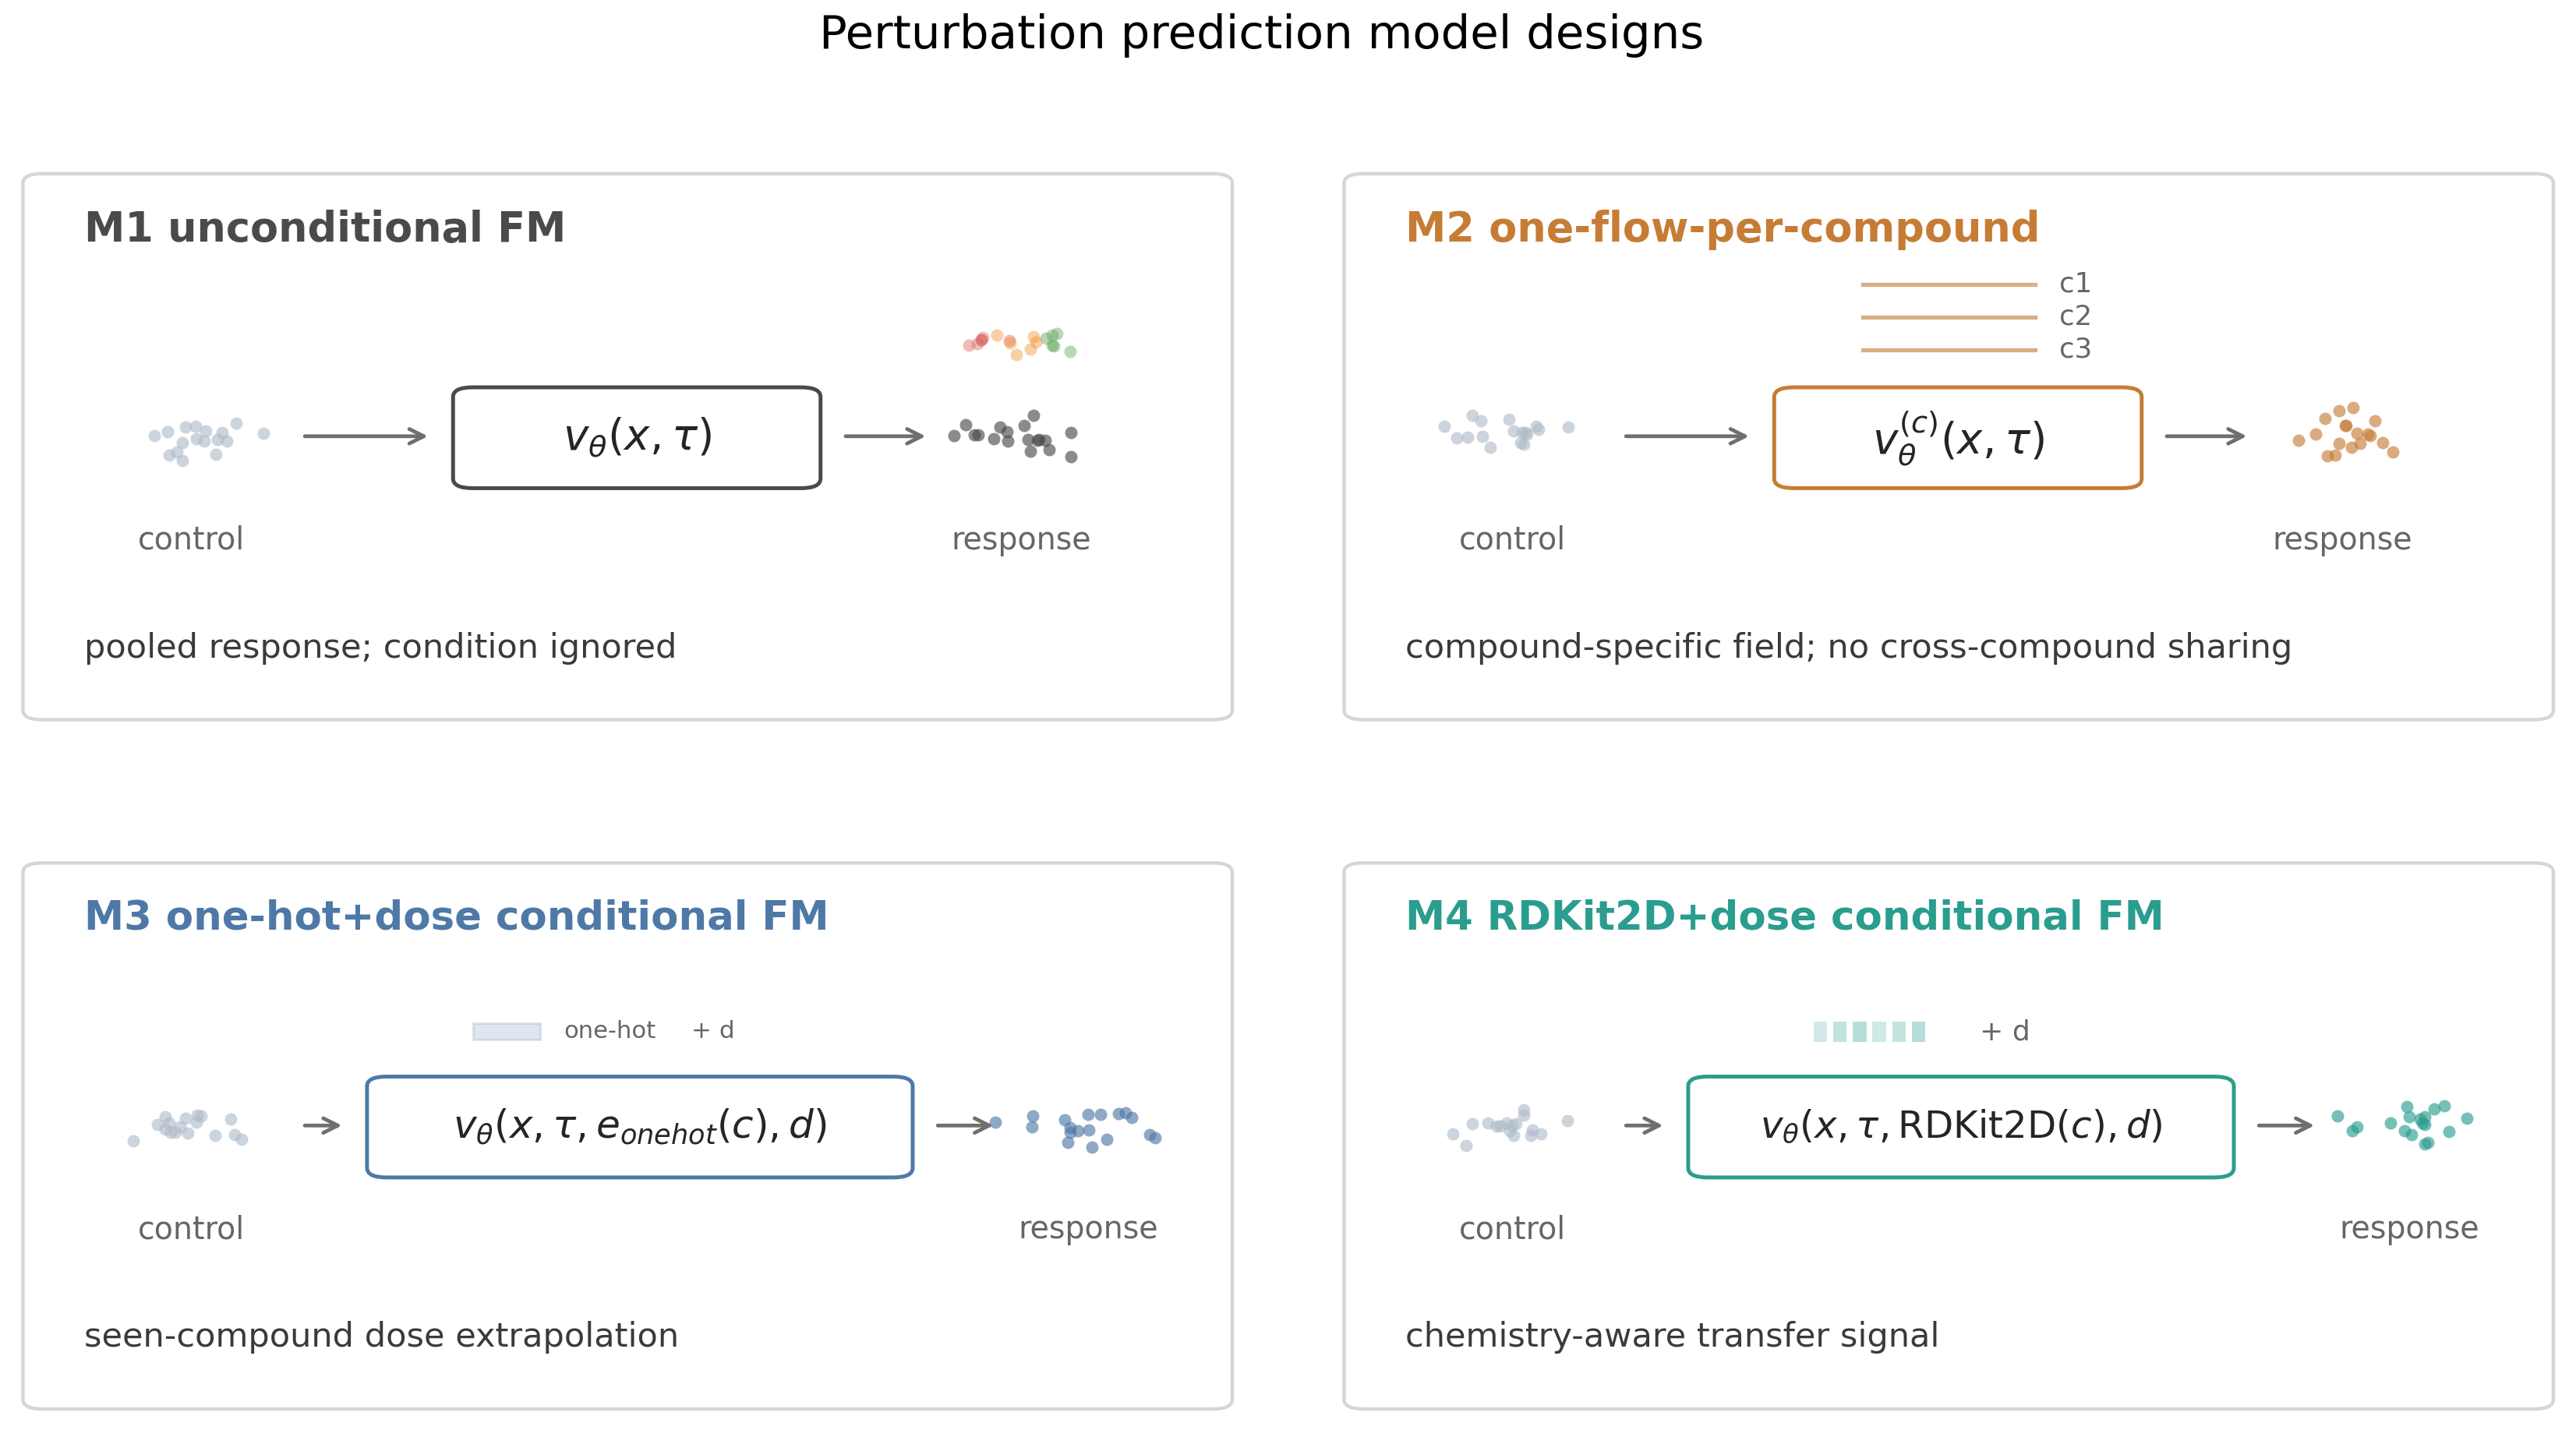

In [15]:

figure_paths["fig_5_2_model_designs"] = ch05s.build_model_design_figure(FIG_DIR, seed=DEFAULT_SEED)
_ = ch05s.display_figure_output(figure_paths["fig_5_2_model_designs"])


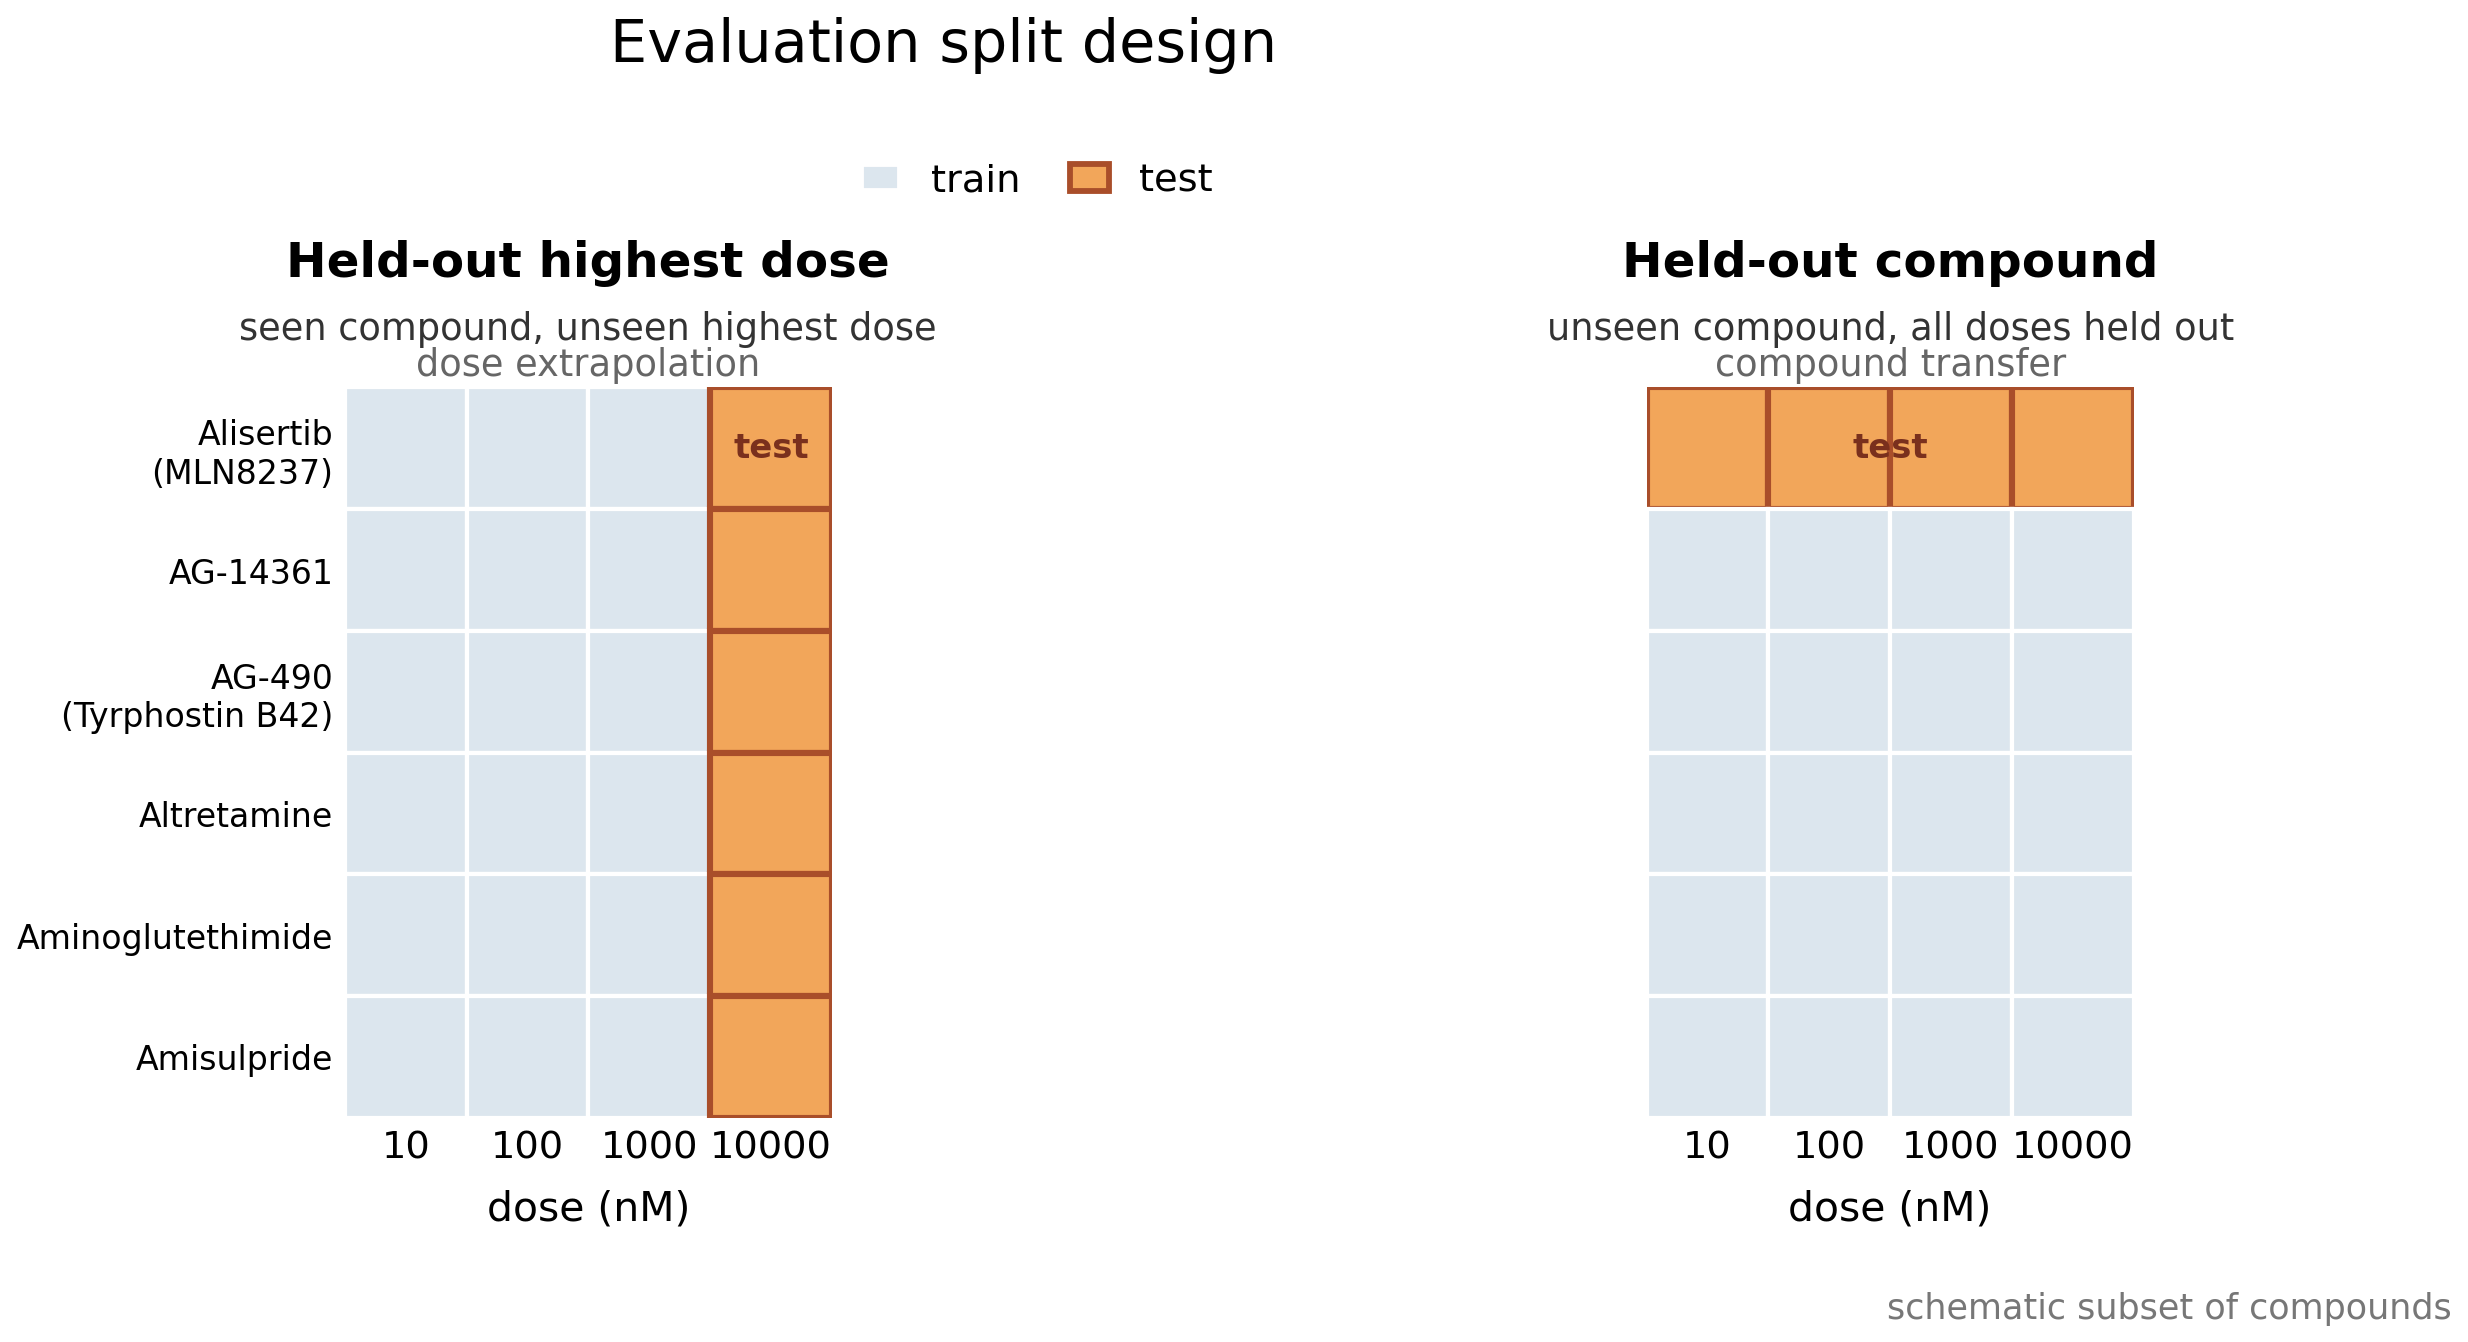

In [16]:

figure_paths["fig_5_2_evaluation_splits"] = ch05s.build_evaluation_split_figure(metadata, split_b, split_c, FIG_DIR)
_ = ch05s.display_figure_output(figure_paths["fig_5_2_evaluation_splits"])


In [17]:

metric_panel_note = "Figure panels use manuscript-synchronized display values; raw cached metrics are retained above for audit."


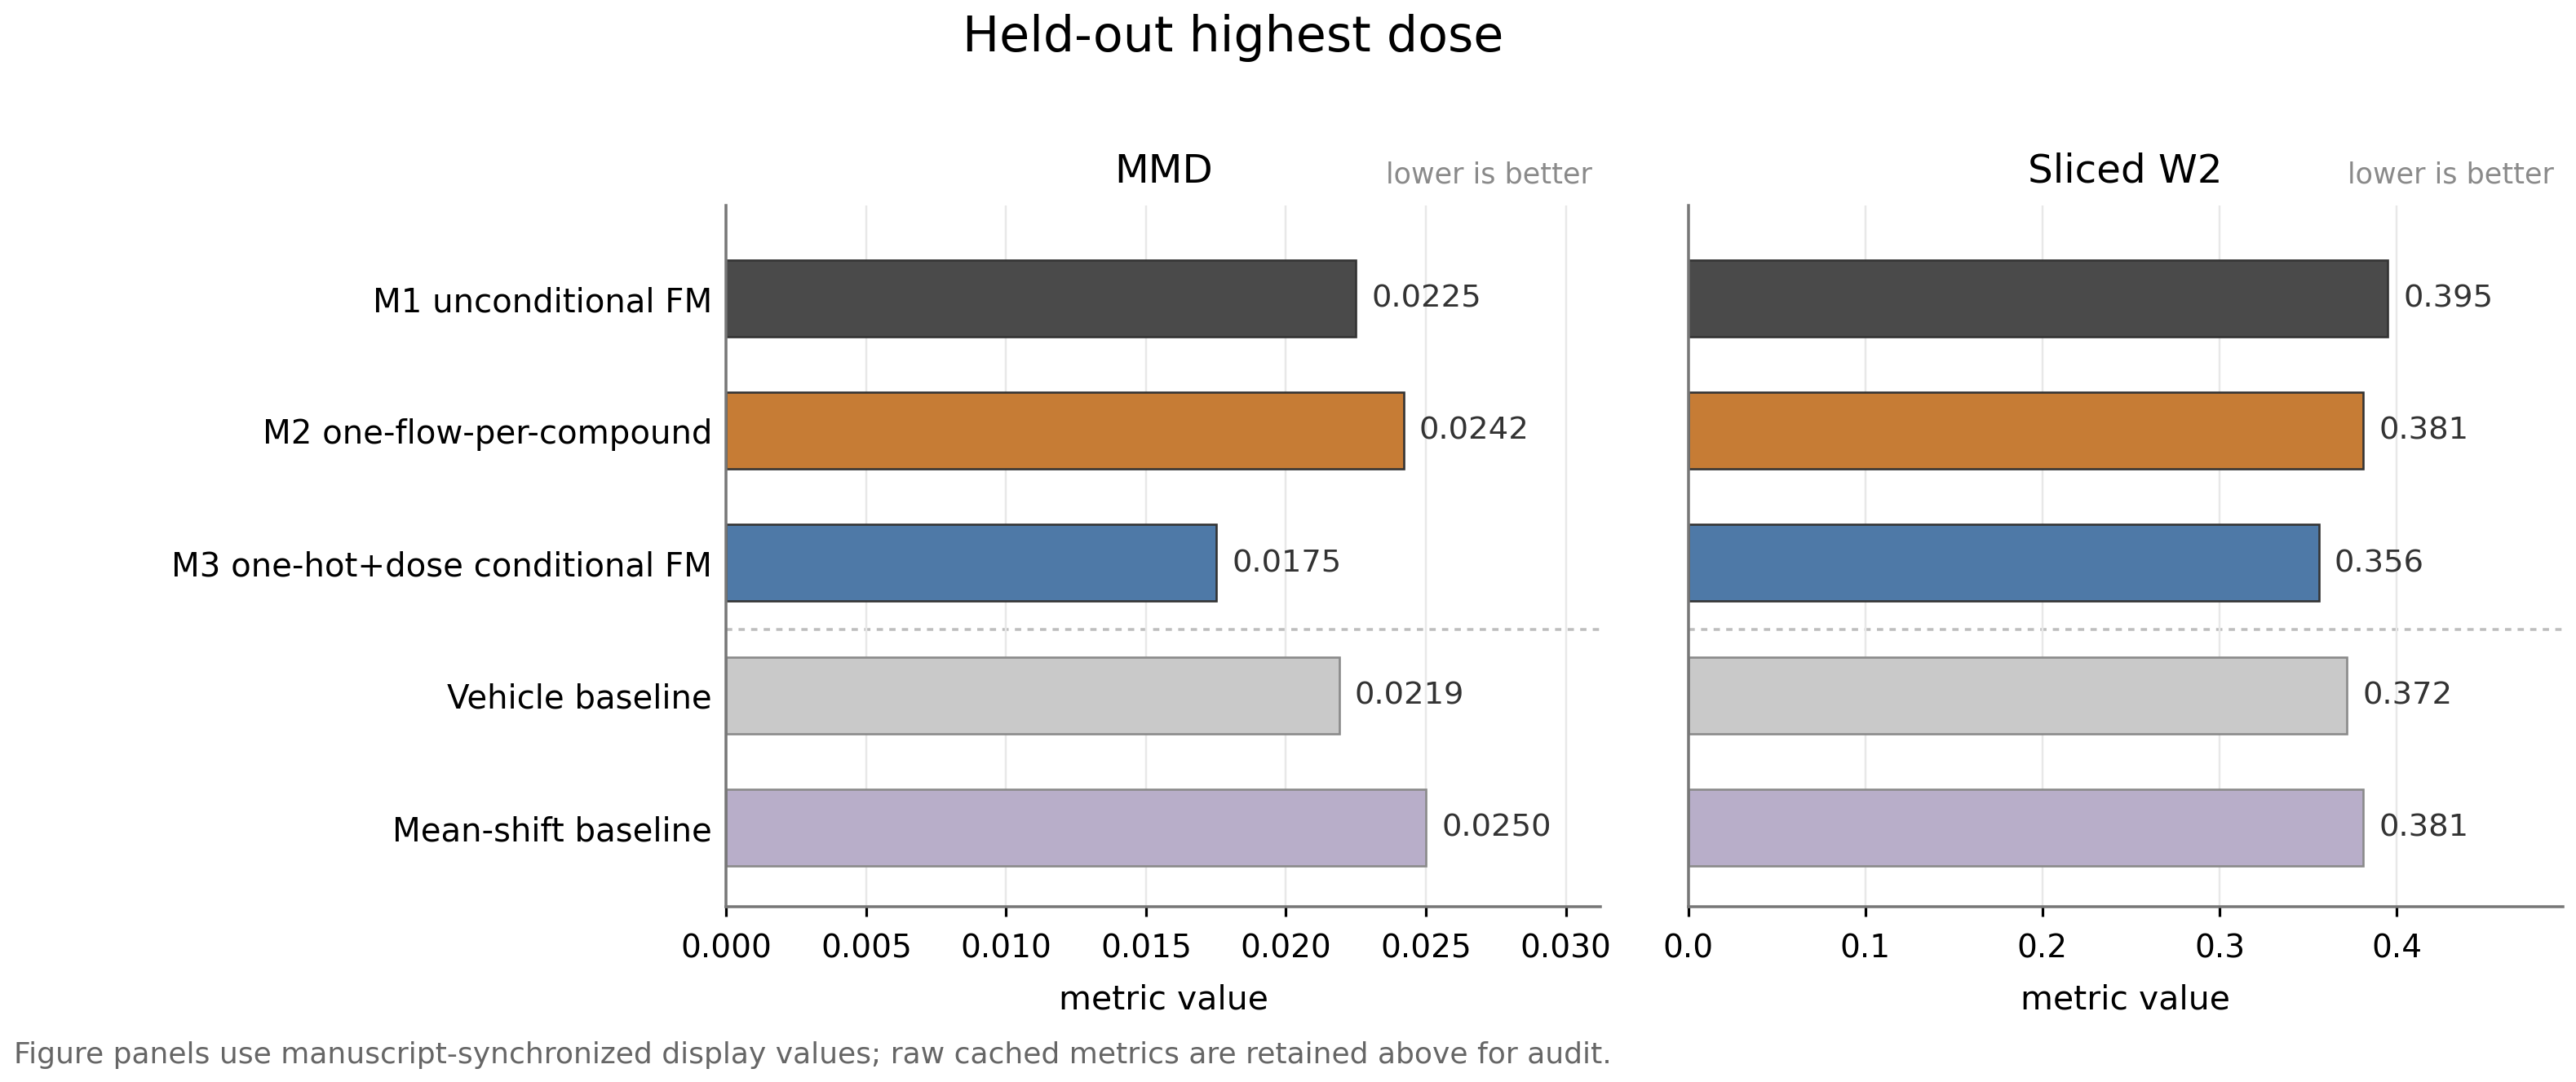

In [18]:

figure_paths["fig_5_2_heldout_highest_dose_metrics"] = ch05s.plot_metric_panel(
    split_b_metric_display,
    FIGURE_TITLES["fig_5_2_heldout_highest_dose_metrics"],
    FIG_DIR,
    "fig_5_2_heldout_highest_dose_metrics",
    note=metric_panel_note,
)
_ = ch05s.display_figure_output(figure_paths["fig_5_2_heldout_highest_dose_metrics"])


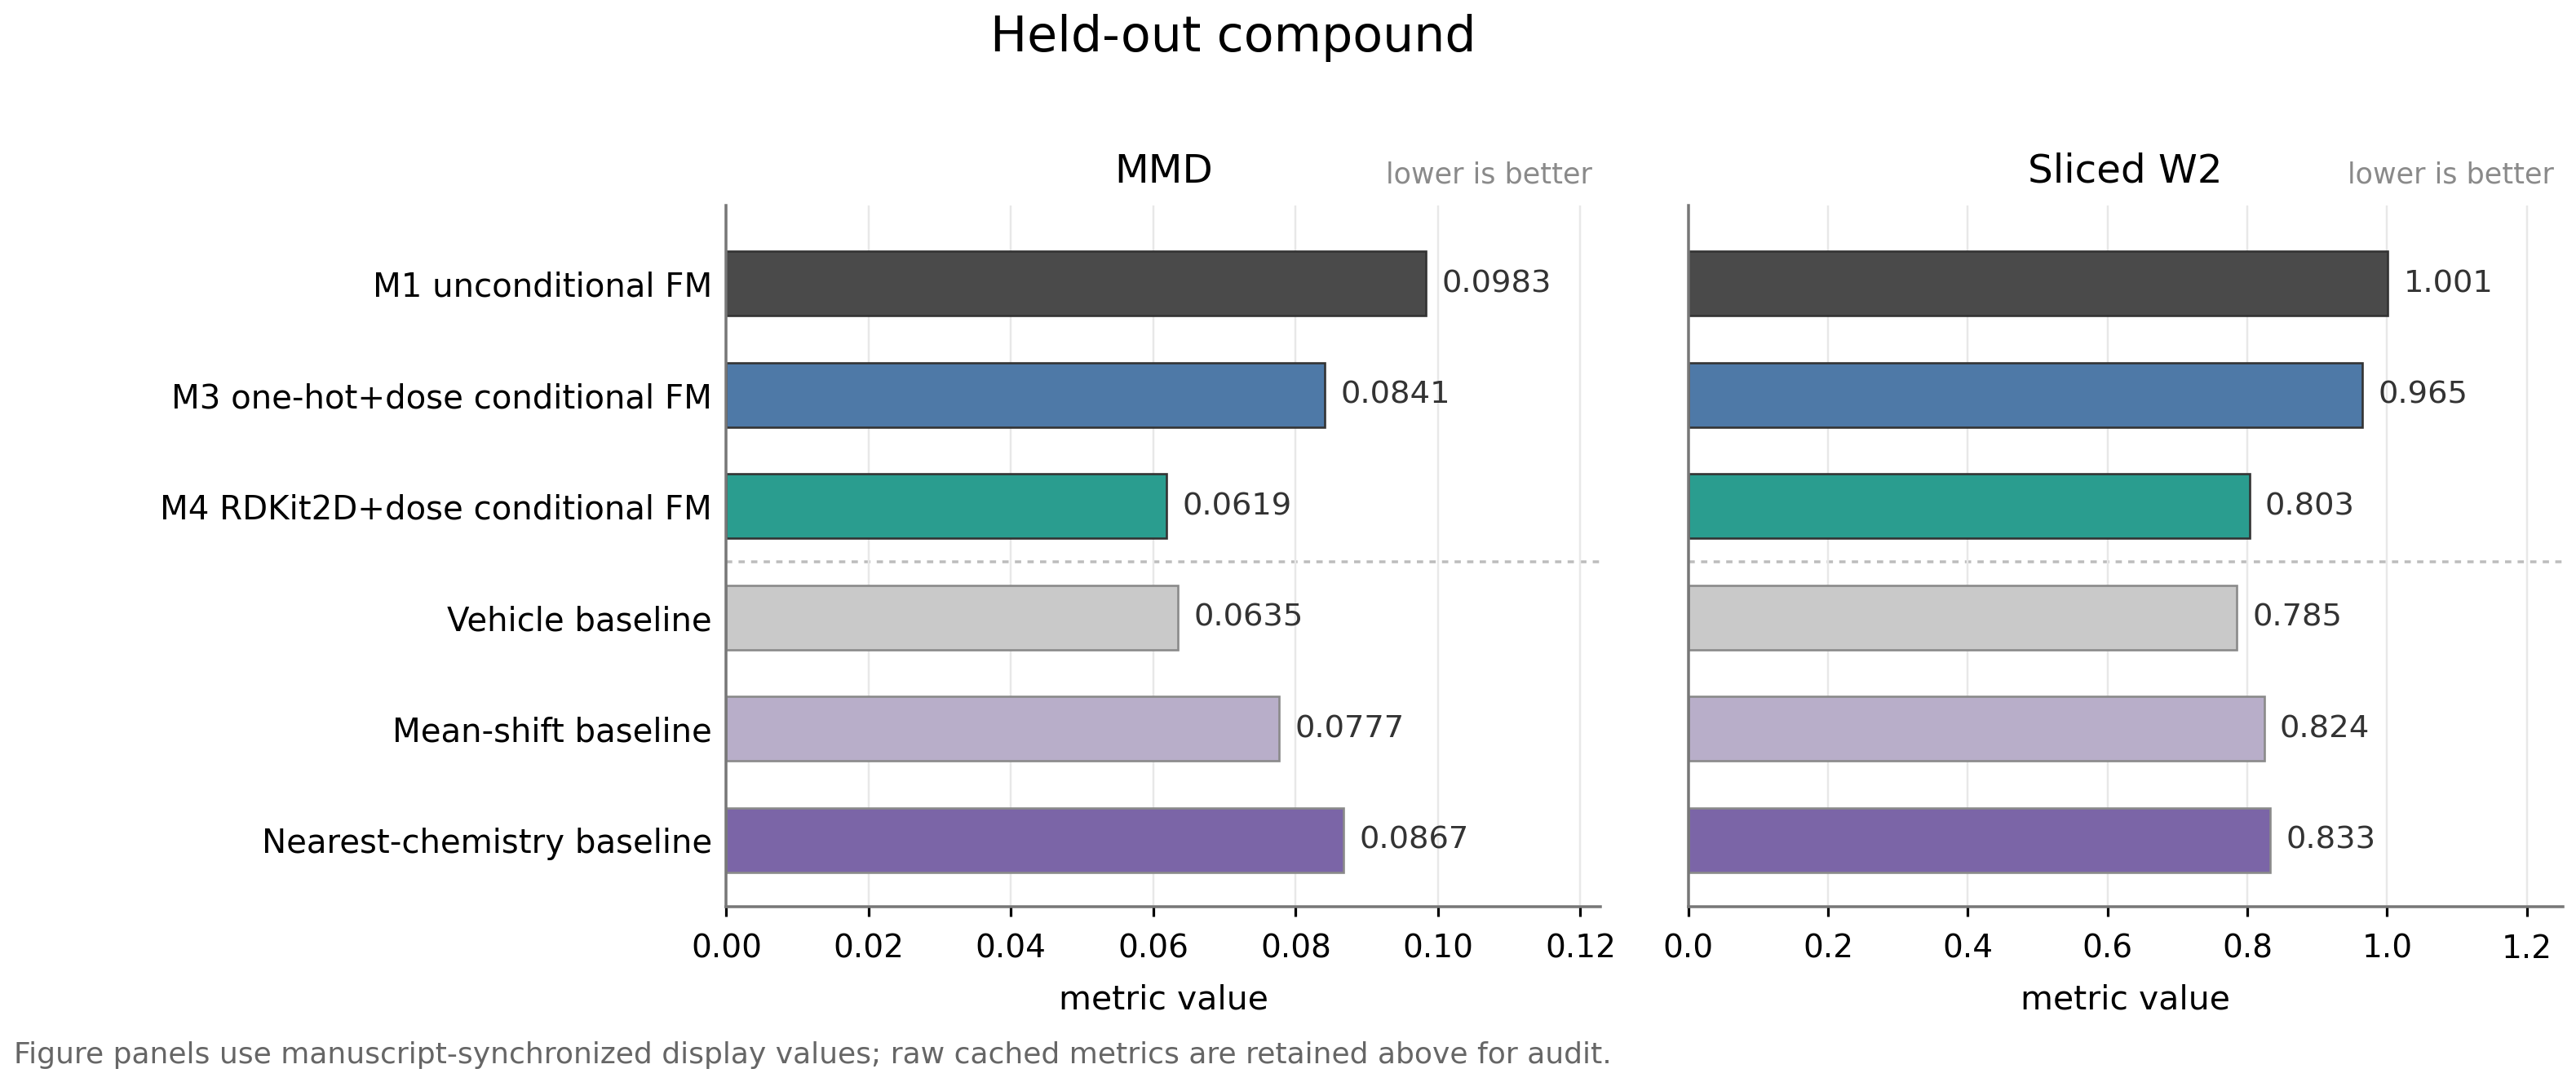

In [19]:

figure_paths["fig_5_2_heldout_compound_metrics"] = ch05s.plot_metric_panel(
    split_c_metric_display,
    FIGURE_TITLES["fig_5_2_heldout_compound_metrics"],
    FIG_DIR,
    "fig_5_2_heldout_compound_metrics",
    note=metric_panel_note,
)
_ = ch05s.display_figure_output(figure_paths["fig_5_2_heldout_compound_metrics"])


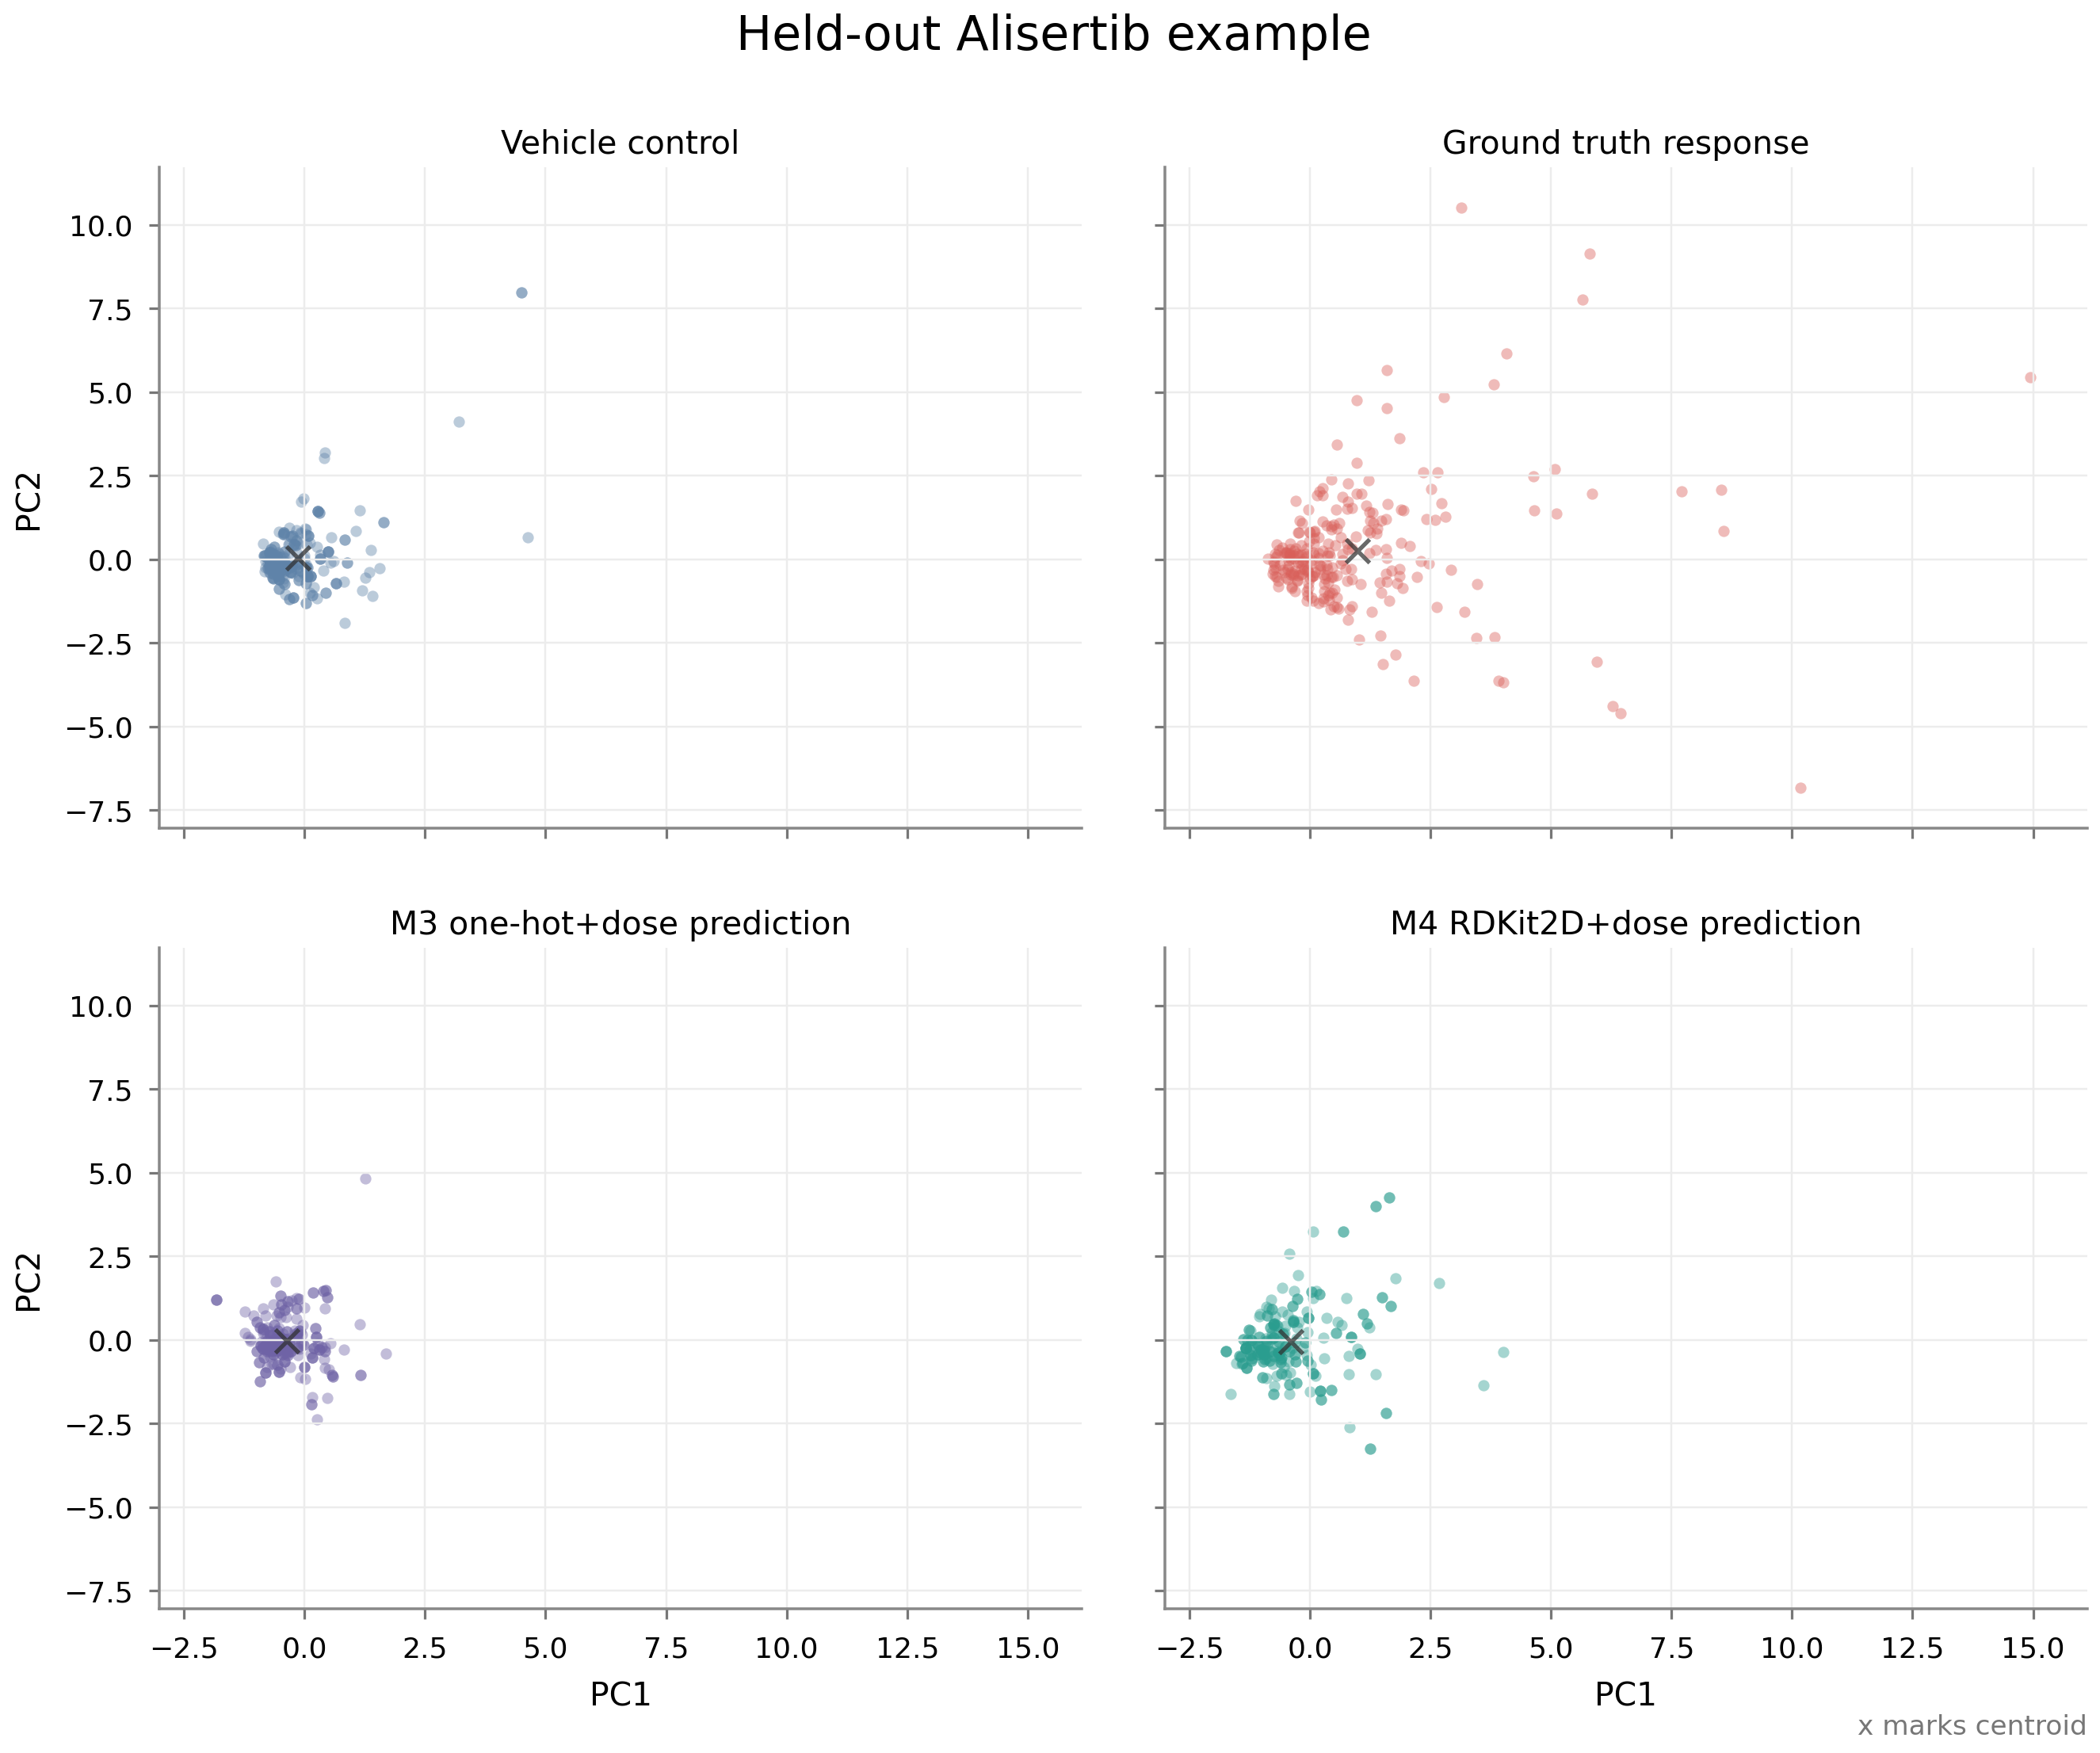

In [20]:
alisertib_keys = [key for key in split_c_cache["predictions"] if "Alisertib" in str(key[0])]
if alisertib_keys:
    representative_key = sorted(alisertib_keys, key=lambda x: x[1])[-1]
else:
    heldout_keys = [key for key in split_c_cache["predictions"] if key[0] == heldout_compound]
    if not heldout_keys:
        heldout_keys = list(split_c_cache["predictions"].keys())
    representative_key = sorted(heldout_keys, key=lambda x: x[1])[-1]
panel = split_c_cache["predictions"][representative_key]

scatter_panels = [
    ("Vehicle control", panel["vehicle_as_prediction"], SCATTER_COLORS["vehicle"]),
    ("Ground truth response", panel["target"], SCATTER_COLORS["truth"]),
    ("M3 one-hot+dose prediction", panel["M3_no_chemistry"], SCATTER_COLORS["m3"]),
    ("M4 RDKit2D+dose prediction", panel["M4_chemistry_aware"], SCATTER_COLORS["m4"]),
]
all_points = np.vstack([np.asarray(points)[:, :2] for _, points, _ in scatter_panels])
x_pad = 0.07 * max(float(all_points[:, 0].max() - all_points[:, 0].min()), 1e-6)
y_pad = 0.07 * max(float(all_points[:, 1].max() - all_points[:, 1].min()), 1e-6)
xlim = (float(all_points[:, 0].min() - x_pad), float(all_points[:, 0].max() + x_pad))
ylim = (float(all_points[:, 1].min() - y_pad), float(all_points[:, 1].max() + y_pad))

fig, axes = plt.subplots(2, 2, figsize=(6.4, 5.45), sharex=True, sharey=True)
for ax, (title, points, color) in zip(axes.ravel(), scatter_panels):
    points = np.asarray(points)
    ax.scatter(points[:, 0], points[:, 1], s=6, alpha=0.42, linewidths=0, color=color, rasterized=True)
    center = points[:, :2].mean(axis=0)
    ax.scatter(center[0], center[1], s=26, marker="x", color="#2F2F2F", linewidths=0.9, alpha=0.72, zorder=3)
    ax.set_title(title, fontsize=7.0, pad=3)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(color="#ECECEC", linewidth=0.42)
    ax.tick_params(labelsize=6.2, length=2.2, width=0.55, color="#777777")
    ax.spines["left"].set_color("#888888")
    ax.spines["bottom"].set_color("#888888")
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)
for ax in axes[:, 0]:
    ax.set_ylabel("PC2", fontsize=7.0)
for ax in axes[-1, :]:
    ax.set_xlabel("PC1", fontsize=7.0)
fig.text(0.985, 0.028, "x marks centroid", ha="right", va="bottom", fontsize=5.9, color="#777777")
fig.suptitle(FIGURE_TITLES["fig_5_2_alisertib_example"], fontsize=10.3, y=0.980)
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.10, top=0.895, wspace=0.09, hspace=0.18)
figure_paths["fig_5_2_alisertib_example"] = ch05s.save_figure_pair(fig, FIG_DIR, "fig_5_2_alisertib_example", tight=False)

RUN_SUMMARY["sciplex_representative_heldout"] = {
    "compound": representative_key[0],
    "dose": representative_key[1],
    "split_name": "Split C held-out compound",
}
_ = ch05s.display_figure_output(figure_paths["fig_5_2_alisertib_example"])


## 6. Metric tables

The final visible tables show the metric values used in the Section 5.2 displays. The artifact completeness and finite-metric checks are folded into `ch05s.build_section52_run_summary`, so the notebook ends with interpretation-facing evidence rather than a manifest table.

### Hypothesis
The final tables assume the interpretation-facing metric values should be shown directly while artifact completeness checks stay inside the summary helper.

### Setup
`metric_frames` collects split-level and display-level metric tables for `build_section52_run_summary`. `metric_value_table` then displays the Split B and Split C metric values used by the Section 5.2 figures, together with `missing_result_notes`.


In [21]:

metric_frames = {
    "split_b_metrics": split_b_metrics,
    "split_c_metrics": split_c_metrics,
    "sciplex_metrics": sciplex_metrics,
    "sciplex_summary": sciplex_summary,
    "split_b_metric_display": split_b_metric_display,
    "split_c_metric_display": split_c_metric_display,
}
section52_summary, required_paths, finite_checks, figure_title_audit = ch05s.build_section52_run_summary(
    run_summary=RUN_SUMMARY,
    config=CONFIG,
    figure_paths=figure_paths,
    metric_frames=metric_frames,
    split_b_metric_display=split_b_metric_display,
    split_c_metric_display=split_c_metric_display,
    representative_key=representative_key,
    manuscript_metric_source=manuscript_metric_source,
    missing_result_notes=missing_result_notes,
)
_ = save_json(OUT_DIR / "run_summary_perturbation_sciplex.json", RUN_SUMMARY)


In [22]:
print("Held-out highest dose metrics used for the figure (lower is better):")
display(ch05s.metric_value_table(split_b_metric_display))
print("Held-out compound metrics used for the figure (lower is better):")
display(ch05s.metric_value_table(split_c_metric_display))
print("Missing or not applicable models/baselines/metrics:")
for note in missing_result_notes:
    print("-", note)


Held-out highest dose metrics used for the figure (lower is better):


,method,MMD,Sliced W2
6,M1 unconditional FM,0.0225,0.395
7,M2 one-flow-per-compound,0.0242,0.381
8,M3 one-hot+dose conditional FM,0.0175,0.356
11,Vehicle baseline,0.0219,0.372
10,Mean-shift baseline,0.0250,0.381


Held-out compound metrics used for the figure (lower is better):


,method,MMD,Sliced W2
12,M1 unconditional FM,0.0983,1.001
13,M3 one-hot+dose conditional FM,0.0841,0.965
14,M4 RDKit2D+dose conditional FM,0.0619,0.803
17,Vehicle baseline,0.0635,0.785
15,Mean-shift baseline,0.0777,0.824
16,Nearest-chemistry baseline,0.0867,0.833


Missing or not applicable models/baselines/metrics:
- M2 one-flow-per-compound is not plotted for held-out compound because an unseen compound has no trained per-compound flow.


## Take-aways

- *Finding 1* — Section 5.2 stays limited to the manuscript's held-out highest-dose and held-out-compound sci-Plex settings.
- *Finding 2* — Split-aware PCA state tables, RDKit2D compound features, and the shared evaluation routine feed both perturbation experiments.
- *Finding 3* — The final Section 5.2 figures and metric tables are generated from live notebook result variables, with artifact checks folded into the run summary.

Next: → end of tutorial suite
